In [1]:
import ann_visualizer
import copy
import datetime
from IPython.display import display, Image, SVG
import logging
import matplotlib.pyplot as plt
import numpy
import os
import pandas
import pickle
import plotly
import pyarrow.parquet as pq
import six
import tensorflow as tf

import CS230

#tf.enable_eager_execution()

# model 5: CNN + LSTM

In [2]:
MODEL_NAME = 'model-5'

DATA_DIR = os.path.join('data', MODEL_NAME)
if not os.path.isdir(DATA_DIR):
    os.mkdir(DATA_DIR)

logger = CS230.common.get_logger()

In [3]:
FILE_PATHS = []

for dir_path, dir_names, file_names in os.walk(CS230.data.DATA_DIR):
    if dir_path.startswith('.'):
        continue
    
    for file_name in file_names:
        if file_name.endswith('.parquet'):
            file_path = os.path.join(dir_path, file_name)
            FILE_PATHS.append(file_path)
    
    if FILE_PATHS:
        break  # exit after loading files from 1 directory

FILE_PATHS.sort()
FILE_PATHS

['/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_01_01_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_01_02_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_02_01_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_03_01_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_03_02_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_03_03_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140221_04_01_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140222_01_01_03_250lm.parquet',
 '/home/dave/code/github/davidcasterton/CS230_project/data/2014_Targa_Sixty-Six/20140222

In [4]:
COLS_X = ['axCG', 'ayCG', 'azCG', 'brake', 'chassisAccelFL', 'chassisAccelFR', 'chassisAccelRL', 'chassisAccelRR', 
              'clutch', 'engineSpeed', 'handwheelAngle', 'deflectionFL', 'deflectionFR',
              'horizontalSpeed', 'pitchAngle', 'pitchRate', 'rollAngle', 'rollRate', 'throttle', 'vxCG', 'vyCG', 'vzCG', 
              'wheelAccelFL', 'wheelAccelFR', 'wheelAccelRL', 'wheelAccelRR', 'yawAngle', 'yawRate']  #'deflectionRL', 'deflectionRR', 

COLS_Y = ['axCG', 'ayCG', 'azCG', 'chassisAccelFL', 'chassisAccelFR', 'chassisAccelRL', 'chassisAccelRR',
               'horizontalSpeed', 'deflectionFL', 'deflectionFR',
               'pitchAngle', 'pitchRate', 'rollAngle', 'rollRate', 'vxCG', 'vyCG', 'vzCG',
               'wheelAccelFL', 'wheelAccelFR', 'wheelAccelRL', 'wheelAccelRR', 'yawAngle', 'yawRate']  #'deflectionRL', 'deflectionRR',  

In [5]:
def get_df_x(file_path, cols=COLS_X):
    df = CS230.data.load(file_path)
    df = CS230.data.stride_rows(df, stride=10)
    df.dropna(axis=0, inplace=True)
    df = df.iloc[:-1].reset_index(drop=True)
    return df[cols]

In [6]:
def get_df_y(file_path, cols=COLS_Y):
    df = CS230.data.load(file_path)
    df = CS230.data.stride_rows(df, stride=10)
    df.dropna(axis=0, inplace=True)
    df = df.iloc[1:].reset_index(drop=True)
    return df[cols]

In [7]:
def get_x(df):
    x = numpy.reshape(df.values, (df.shape[0], 1, df.shape[1]))
    x = tf.cast(x, tf.float64)
    return x

In [8]:
def get_y(df):
    y = tf.cast(df.values, tf.float64)
    return y

In [9]:
DATA = {}

for name, file_path in [('train', FILE_PATHS[0]), ('dev', FILE_PATHS[1])]:
    DATA[name] = {'df': {}, 'tensor': {}}
    DATA[name]['df']['x'] = get_df_x(file_path)
    DATA[name]['df']['y'] = get_df_y(file_path)
    DATA[name]['tensor']['x'] = get_x(DATA[name]['df']['x'])
    DATA[name]['tensor']['y'] = get_y(DATA[name]['df']['y'])
    
    DATA[name]['m'] = DATA[name]['df']['x'].shape[0]
    DATA[name]['n_x'] = DATA[name]['df']['x'].shape[1]
    DATA[name]['n_y'] = DATA[name]['df']['y'].shape[1]

In [16]:
for set_name, _dict in six.iteritems(DATA):
    for name, df in six.iteritems(_dict['df']):
        print('%s %s %s' % (set_name, name, df.shape))
        display(df.head())
    print('%s m: %s' % (set_name, _dict['m']))
    print('%s n_x: %s' % (set_name, _dict['n_x']))
    print('%s n_y: %s' % (set_name, _dict['n_y']))
    print('\n')

train x (49095, 28)


,axCG,ayCG,azCG,brake,chassisAccelFL,chassisAccelFR,chassisAccelRL,chassisAccelRR,clutch,engineSpeed,...,throttle,vxCG,vyCG,vzCG,wheelAccelFL,wheelAccelFR,wheelAccelRL,wheelAccelRR,yawAngle,yawRate
0,0.94,0.23,7.78,0.0,9.300,9.398,7.564,10.094,0.0,1890,...,11.8,6.12,-0.27,-0.22,8.63,10.30,10.99,7.06,-14.01,5.81
1,0.94,0.23,7.78,0.0,8.545,10.094,9.398,9.781,0.0,1890,...,11.8,6.13,-0.28,-0.24,8.73,9.52,12.07,7.85,-13.96,5.81
2,0.94,0.23,7.78,0.0,9.349,9.663,9.594,10.889,0.0,1914,...,11.8,6.13,-0.28,-0.26,7.75,10.59,10.20,9.12,-13.90,5.81
3,0.19,1.52,10.73,0.0,9.300,9.320,8.584,10.860,0.0,1914,...,11.8,6.12,-0.26,-0.24,8.63,11.38,9.81,9.71,-13.91,5.32
4,0.19,1.52,10.73,0.0,9.349,8.427,7.279,10.359,0.0,1914,...,12.0,6.11,-0.25,-0.23,9.71,9.71,7.95,10.50,-13.86,5.32


train y (49095, 23)


,axCG,ayCG,azCG,chassisAccelFL,chassisAccelFR,chassisAccelRL,chassisAccelRR,horizontalSpeed,deflectionFL,deflectionFR,...,rollRate,vxCG,vyCG,vzCG,wheelAccelFL,wheelAccelFR,wheelAccelRL,wheelAccelRR,yawAngle,yawRate
0,0.94,0.23,7.78,8.545,10.094,9.398,9.781,6.14,0.002,0.000,...,-3.60,6.13,-0.28,-0.24,8.73,9.52,12.07,7.85,-13.96,5.81
1,0.94,0.23,7.78,9.349,9.663,9.594,10.889,6.14,0.002,0.001,...,-3.60,6.13,-0.28,-0.26,7.75,10.59,10.20,9.12,-13.90,5.81
2,0.19,1.52,10.73,9.300,9.320,8.584,10.860,6.13,0.002,0.001,...,2.02,6.12,-0.26,-0.24,8.63,11.38,9.81,9.71,-13.91,5.32
3,0.19,1.52,10.73,9.349,8.427,7.279,10.359,6.12,0.002,0.001,...,2.02,6.11,-0.25,-0.23,9.71,9.71,7.95,10.50,-13.86,5.32
4,0.19,1.52,10.73,9.977,9.879,6.818,11.174,6.12,0.002,0.001,...,2.02,6.11,-0.25,-0.22,10.40,8.63,7.65,9.61,-13.81,5.32


train m: 49095
train n_x: 28
train n_y: 23


dev x (79099, 28)


,axCG,ayCG,azCG,brake,chassisAccelFL,chassisAccelFR,chassisAccelRL,chassisAccelRR,clutch,engineSpeed,...,throttle,vxCG,vyCG,vzCG,wheelAccelFL,wheelAccelFR,wheelAccelRL,wheelAccelRR,yawAngle,yawRate
0,0.36,-0.56,9.80,0.0,9.83,9.928,9.163,9.182,0.0,0,...,0.2,-0.01,-0.02,0.02,10.2,9.91,8.14,7.85,-4.31,0.56
1,-0.24,0.66,9.83,0.0,9.81,9.928,9.163,9.153,0.0,0,...,0.2,-0.01,-0.01,0.02,10.4,10.10,8.14,8.04,-4.31,0.06
2,-0.19,0.54,9.56,0.0,9.83,9.898,9.182,9.133,0.0,0,...,0.2,-0.01,-0.01,0.01,10.5,10.10,8.44,7.85,-4.30,-0.32
3,0.05,0.08,9.97,0.0,9.83,9.898,9.231,9.182,0.0,0,...,0.2,-0.01,-0.01,0.02,10.3,9.71,8.24,8.14,-4.30,-0.21
4,0.14,-0.08,9.67,0.0,9.83,9.898,9.212,9.202,0.0,0,...,0.2,-0.01,-0.01,0.02,10.3,10.10,8.14,7.95,-4.29,0.09


dev y (79099, 23)


,axCG,ayCG,azCG,chassisAccelFL,chassisAccelFR,chassisAccelRL,chassisAccelRR,horizontalSpeed,deflectionFL,deflectionFR,...,rollRate,vxCG,vyCG,vzCG,wheelAccelFL,wheelAccelFR,wheelAccelRL,wheelAccelRR,yawAngle,yawRate
0,-0.24,0.66,9.83,9.81,9.928,9.163,9.153,0.01,0.001,-0.001,...,-0.18,-0.01,-0.01,0.02,10.40,10.10,8.14,8.04,-4.31,0.06
1,-0.19,0.54,9.56,9.83,9.898,9.182,9.133,0.01,0.001,-0.001,...,0.22,-0.01,-0.01,0.01,10.50,10.10,8.44,7.85,-4.30,-0.32
2,0.05,0.08,9.97,9.83,9.898,9.231,9.182,0.01,0.001,-0.001,...,-0.13,-0.01,-0.01,0.02,10.30,9.71,8.24,8.14,-4.30,-0.21
3,0.14,-0.08,9.67,9.83,9.898,9.212,9.202,0.01,0.001,-0.001,...,0.21,-0.01,-0.01,0.02,10.30,10.10,8.14,7.95,-4.29,0.09
4,-0.09,0.40,10.06,9.83,9.898,9.163,9.182,0.01,0.001,-0.001,...,-0.21,-0.01,-0.01,0.02,10.01,9.91,8.14,7.75,-4.29,-0.13


dev m: 79099
dev n_x: 28
dev n_y: 23




_________________________________________________________________
Layer (type)                 Output Shape              Param #   
lstm_2 (LSTM)                (None, 1, 28)             6384      
_________________________________________________________________
batch_normalization_v1_2 (Ba (None, 1, 28)             112       
_________________________________________________________________
lstm_3 (LSTM)                (None, 28)                6384      
_________________________________________________________________
batch_normalization_v1_3 (Ba (None, 28)                112       
_________________________________________________________________
dropout_1 (Dropout)          (None, 28)                0         
_________________________________________________________________
dense_1 (Dense)              (None, 23)                667       
Total params: 13,659
Trainable params: 13,547
Non-trainable params: 112
_________________________________________________________________


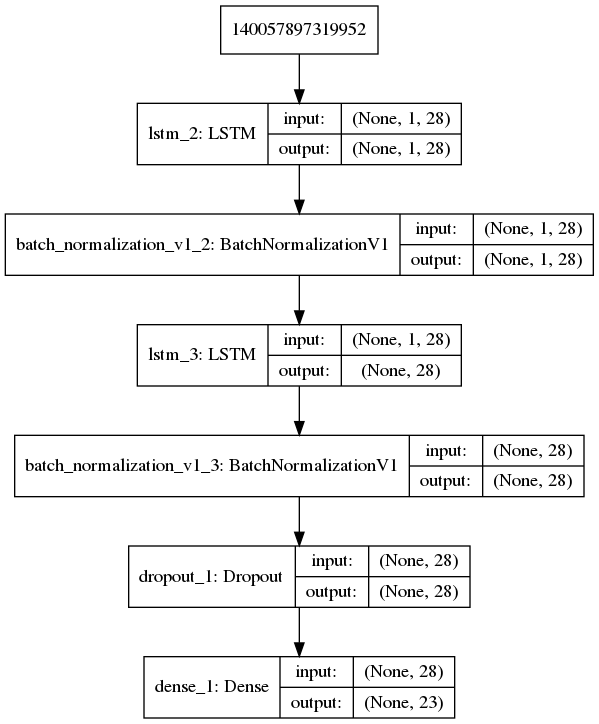

In [17]:
m = DATA['train']['m']
n_x = DATA['train']['n_x']
n_y = DATA['train']['n_y']

# build model
model = tf.keras.Sequential()

model.add(tf.keras.layers.LSTM(n_x, return_sequences=True, input_shape=(1, n_x), dropout=0.1, recurrent_dropout=0.1))

model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.LSTM(n_x, dropout=0.1, recurrent_dropout=0.1))

model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.Dropout(0.2))
model.add(tf.keras.layers.Dense(n_y, activation='linear'))

# summarize model
model.summary()

# visualize model
file_path = os.path.join(DATA_DIR, 'model.png')
tf.keras.utils.plot_model(model, file_path, show_shapes=True, show_layer_names=True)
display(Image(filename=file_path))

In [18]:
#optimizer = tf.train.AdamOptimizer(0.01)
optimizer = tf.keras.optimizers.Adam(0.01, decay=0.0001)
#optimizer = tf.keras.optimizers.SGD(lr=0.03, decay=1e-6, momentum=0.9, nesterov=True)

model.compile(
    optimizer=optimizer, 
    loss='mean_squared_error', 
    metrics=['mean_absolute_error']
)

In [19]:
checkpoint_path = os.path.join(DATA_DIR, 'cp.ckpt')
cp_callback = tf.keras.callbacks.ModelCheckpoint(checkpoint_path, monitor='mean_absolute_error', verbose=1, save_weights_only=True, save_best_only=True, mode='max')

In [20]:
history = model.fit(
    DATA['train']['tensor']['x'], DATA['train']['tensor']['y'], 
    epochs=50, steps_per_epoch=50, callbacks = [cp_callback]
)

Instructions for updating:
Use tf.cast instead.
Epoch 1/50
49/50 [============================>.] - ETA: 0s - loss: 272.9831 - mean_absolute_error: 6.2249
Epoch 00001: mean_absolute_error improved from -inf to 6.18862, saving model to data/model-5/cp.ckpt

Consider using a TensorFlow optimizer from `tf.train`.
Instructions for updating:
Use tf.train.CheckpointManager to manage checkpoints rather than manually editing the Checkpoint proto.
50/50 [==============================] - 2s 45ms/step - loss: 271.2158 - mean_absolute_error: 6.1886
Epoch 2/50
49/50 [============================>.] - ETA: 0s - loss: 133.3885 - mean_absolute_error: 3.4389
Epoch 00002: mean_absolute_error did not improve from 6.18862
50/50 [==============================] - 1s 19ms/step - loss: 132.7622 - mean_absolute_error: 3.4302
Epoch 3/50
49/50 [============================>.] - ETA: 0s - loss: 96.8504 - mean_absolute_error: 2.8796
Epoch 00003: mean_absolute_error did not improve from 6.18862
50/50 [===========

49/50 [============================>.] - ETA: 0s - loss: 213.0700 - mean_absolute_error: 3.3709
Epoch 00027: mean_absolute_error did not improve from 6.18862
50/50 [==============================] - 1s 19ms/step - loss: 213.0641 - mean_absolute_error: 3.3708
Epoch 28/50
49/50 [============================>.] - ETA: 0s - loss: 212.9595 - mean_absolute_error: 3.3675
Epoch 00028: mean_absolute_error did not improve from 6.18862
50/50 [==============================] - 1s 20ms/step - loss: 212.9412 - mean_absolute_error: 3.3673
Epoch 29/50
49/50 [============================>.] - ETA: 0s - loss: 212.6839 - mean_absolute_error: 3.3621
Epoch 00029: mean_absolute_error did not improve from 6.18862
50/50 [==============================] - 1s 20ms/step - loss: 212.6710 - mean_absolute_error: 3.3621
Epoch 30/50
49/50 [============================>.] - ETA: 0s - loss: 212.8043 - mean_absolute_error: 3.3608
Epoch 00030: mean_absolute_error did not improve from 6.18862
50/50 [======================

Text(0.5, 0, 'epoch')

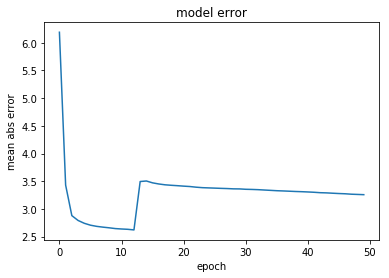

In [21]:
plt.plot(history.history['mean_absolute_error'])
#plt.plot(history.history['val_acc'])
plt.title('model error')
plt.ylabel('mean abs error')
plt.xlabel('epoch')

In [22]:
model.save(os.path.join(DATA_DIR, 'model_%s.h5' % datetime.datetime.now().strftime("%Y%m%d-%H%M%S")))

In [23]:
predictions = model.predict(DATA['dev']['tensor']['x'], steps=1)

In [26]:
df_predictions = pandas.DataFrame(predictions, columns=COLS_Y)

In [27]:
DATA['dev']['df']['x'].head()

,axCG,ayCG,azCG,brake,chassisAccelFL,chassisAccelFR,chassisAccelRL,chassisAccelRR,clutch,engineSpeed,...,throttle,vxCG,vyCG,vzCG,wheelAccelFL,wheelAccelFR,wheelAccelRL,wheelAccelRR,yawAngle,yawRate
0,0.36,-0.56,9.80,0.0,9.83,9.928,9.163,9.182,0.0,0,...,0.2,-0.01,-0.02,0.02,10.2,9.91,8.14,7.85,-4.31,0.56
1,-0.24,0.66,9.83,0.0,9.81,9.928,9.163,9.153,0.0,0,...,0.2,-0.01,-0.01,0.02,10.4,10.10,8.14,8.04,-4.31,0.06
2,-0.19,0.54,9.56,0.0,9.83,9.898,9.182,9.133,0.0,0,...,0.2,-0.01,-0.01,0.01,10.5,10.10,8.44,7.85,-4.30,-0.32
3,0.05,0.08,9.97,0.0,9.83,9.898,9.231,9.182,0.0,0,...,0.2,-0.01,-0.01,0.02,10.3,9.71,8.24,8.14,-4.30,-0.21
4,0.14,-0.08,9.67,0.0,9.83,9.898,9.212,9.202,0.0,0,...,0.2,-0.01,-0.01,0.02,10.3,10.10,8.14,7.95,-4.29,0.09


In [28]:
DATA['dev']['df']['y'].head()

,axCG,ayCG,azCG,chassisAccelFL,chassisAccelFR,chassisAccelRL,chassisAccelRR,horizontalSpeed,deflectionFL,deflectionFR,...,rollRate,vxCG,vyCG,vzCG,wheelAccelFL,wheelAccelFR,wheelAccelRL,wheelAccelRR,yawAngle,yawRate
0,-0.24,0.66,9.83,9.81,9.928,9.163,9.153,0.01,0.001,-0.001,...,-0.18,-0.01,-0.01,0.02,10.40,10.10,8.14,8.04,-4.31,0.06
1,-0.19,0.54,9.56,9.83,9.898,9.182,9.133,0.01,0.001,-0.001,...,0.22,-0.01,-0.01,0.01,10.50,10.10,8.44,7.85,-4.30,-0.32
2,0.05,0.08,9.97,9.83,9.898,9.231,9.182,0.01,0.001,-0.001,...,-0.13,-0.01,-0.01,0.02,10.30,9.71,8.24,8.14,-4.30,-0.21
3,0.14,-0.08,9.67,9.83,9.898,9.212,9.202,0.01,0.001,-0.001,...,0.21,-0.01,-0.01,0.02,10.30,10.10,8.14,7.95,-4.29,0.09
4,-0.09,0.40,10.06,9.83,9.898,9.163,9.182,0.01,0.001,-0.001,...,-0.21,-0.01,-0.01,0.02,10.01,9.91,8.14,7.75,-4.29,-0.13


In [29]:
df_predictions.head()

,axCG,ayCG,azCG,chassisAccelFL,chassisAccelFR,chassisAccelRL,chassisAccelRR,horizontalSpeed,deflectionFL,deflectionFR,...,rollRate,vxCG,vyCG,vzCG,wheelAccelFL,wheelAccelFR,wheelAccelRL,wheelAccelRR,yawAngle,yawRate
0,-0.007141,0.174641,9.405127,9.4681,9.530517,8.862398,8.842042,0.287469,0.002098,0.000216,...,-0.003485,0.268404,-0.0011,-0.004135,9.796349,9.518855,7.890577,7.7289,-4.429233,0.013734
1,-0.007141,0.174641,9.405127,9.4681,9.530517,8.862398,8.842042,0.287469,0.002098,0.000216,...,-0.003485,0.268404,-0.0011,-0.004135,9.796349,9.518855,7.890577,7.7289,-4.429233,0.013734
2,-0.007141,0.174641,9.405127,9.4681,9.530517,8.862398,8.842042,0.287469,0.002098,0.000216,...,-0.003485,0.268404,-0.0011,-0.004135,9.796349,9.518855,7.890577,7.7289,-4.429233,0.013734
3,-0.007141,0.174641,9.405127,9.4681,9.530517,8.862398,8.842042,0.287469,0.002098,0.000216,...,-0.003485,0.268404,-0.0011,-0.004135,9.796349,9.518855,7.890577,7.7289,-4.429233,0.013734
4,-0.007141,0.174641,9.405127,9.4681,9.530517,8.862398,8.842042,0.287469,0.002098,0.000216,...,-0.003485,0.268404,-0.0011,-0.004135,9.796349,9.518855,7.890577,7.7289,-4.429233,0.013734


In [31]:
error = DATA['dev']['df']['y'].reset_index(drop=True)[COLS_Y] - df_predictions[COLS_Y]

In [32]:
error.head()

,axCG,ayCG,azCG,chassisAccelFL,chassisAccelFR,chassisAccelRL,chassisAccelRR,horizontalSpeed,deflectionFL,deflectionFR,...,rollRate,vxCG,vyCG,vzCG,wheelAccelFL,wheelAccelFR,wheelAccelRL,wheelAccelRR,yawAngle,yawRate
0,-0.232859,0.485359,0.424873,0.3419,0.397483,0.300602,0.310958,-0.277469,-0.001098,-0.001216,...,-0.176515,-0.278404,-0.0089,0.024135,0.603651,0.581145,0.249423,0.3111,0.119233,0.046266
1,-0.182859,0.365359,0.154873,0.3619,0.367483,0.319602,0.290958,-0.277469,-0.001098,-0.001216,...,0.223485,-0.278404,-0.0089,0.014135,0.703651,0.581145,0.549423,0.1211,0.129233,-0.333734
2,0.057141,-0.094641,0.564873,0.3619,0.367483,0.368602,0.339958,-0.277469,-0.001098,-0.001216,...,-0.126515,-0.278404,-0.0089,0.024135,0.503651,0.191145,0.349423,0.4111,0.129233,-0.223734
3,0.147141,-0.254641,0.264873,0.3619,0.367483,0.349602,0.359958,-0.277469,-0.001098,-0.001216,...,0.213485,-0.278404,-0.0089,0.024135,0.503651,0.581145,0.249423,0.2211,0.139233,0.076266
4,-0.082859,0.225359,0.654873,0.3619,0.367483,0.300602,0.339958,-0.277469,-0.001098,-0.001216,...,-0.206515,-0.278404,-0.0089,0.024135,0.213651,0.391145,0.249423,0.0211,0.139233,-0.143734


In [34]:
error.max()

axCG                 8.792970
ayCG                13.739564
azCG                17.864533
chassisAccelFL       7.169303
chassisAccelFR       7.422839
chassisAccelRL      15.481713
chassisAccelRR      13.933705
horizontalSpeed     34.617131
deflectionFL         0.027208
deflectionFR         0.014432
pitchAngle           1.546546
pitchRate            8.590622
rollAngle            2.873159
rollRate            26.605134
vxCG                34.623756
vyCG                 1.152559
vzCG                 1.382109
wheelAccelFL        38.457254
wheelAccelFR        35.529393
wheelAccelRL        37.798623
wheelAccelRR        41.336191
yawAngle           142.022683
yawRate             32.335961
dtype: float64

In [33]:
error.mean()

axCG               0.074073
ayCG              -0.098835
azCG               0.210148
chassisAccelFL     0.185125
chassisAccelFR     0.197329
chassisAccelRL    -0.023926
chassisAccelRR     0.115167
horizontalSpeed    2.187008
deflectionFL       0.001557
deflectionFR      -0.002515
pitchAngle        -0.025550
pitchRate          0.052727
rollAngle         -0.037183
rollRate          -0.016727
vxCG               2.191399
vyCG               0.029566
vzCG              -0.007956
wheelAccelFL       0.378484
wheelAccelFR       0.291344
wheelAccelRL      -0.084887
wheelAccelRR       0.207208
yawAngle          -5.301614
yawRate           -0.268279
dtype: float64